**Bivariate Analysis**

- Numerical v/s Numerical: Scatterplot, Correlation
- Numerical v/s Categorical: Boxplot, Group Statistics
- Categorical v/s Categorical: Crosstab, Countplot

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

**1. Load Dataset**

In [2]:
df = pd.read_csv("titanic_dataset.csv")

In [3]:
df.shape

(891, 15)

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [6]:
num_cols = ["age", "fare", "sibsp","parch"]
cat_cols = ["survived", "pclass", "sex", "embarked", "class", "who", "adult_male", "deck", "embark_town", "alone"]

print("Numerical Columns:\n",num_cols)
print("Categorical Columns:\n",cat_cols)

Numerical Columns:
 ['age', 'fare', 'sibsp', 'parch']
Categorical Columns:
 ['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone']


In [8]:
df_num = df[num_cols].dropna()

In [9]:
df_num.head()

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


In [10]:
df["survived_label"] = df["survived"].map({0: "No", 1: "Yes"})

In [11]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


**2. Numerical v/s Numerical**

**2.1 Scatter Plot**

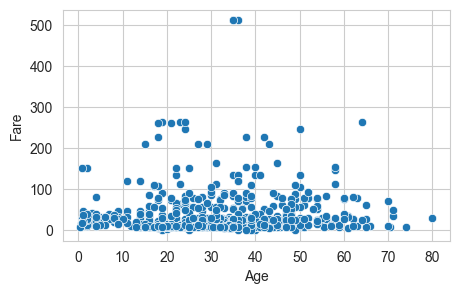

In [13]:
plt.figure(figsize=(5,3))
sns.scatterplot(x = df["age"], y = df["fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

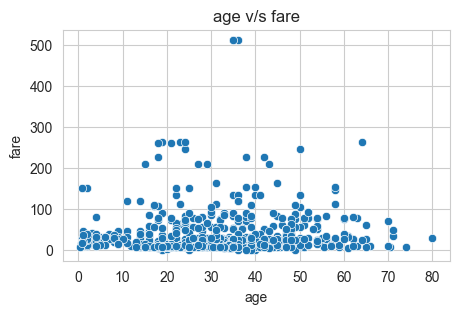

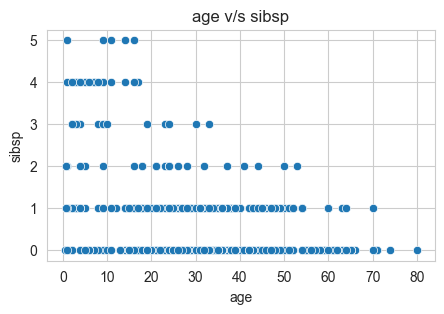

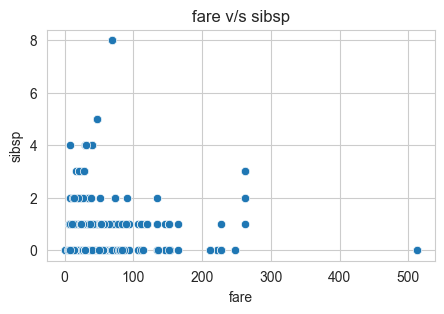

In [14]:
num_pairs = [
    ("age", "fare"),
    ("age", "sibsp"),
    ("fare", "sibsp")
]

for x,y in num_pairs:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x = df[x], y = df[y])
    plt.title(f"{x} v/s {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

**2.2 Correlation Matrix**

In [15]:
print("Correlation Matrix")
df_num.corr()

Correlation Matrix


,age,fare,sibsp,parch
age,1.000000,0.096067,-0.308247,-0.189119
fare,0.096067,1.000000,0.138329,0.205119
sibsp,-0.308247,0.138329,1.000000,0.383820
parch,-0.189119,0.205119,0.383820,1.000000


In [17]:
print("Pearson Correlation with fare")
for col in num_cols:
    if col != "fare":
        r, p = pearsonr(df_num[col], df_num["fare"])
        print(f"{col} v/s fare: r={r:.3f}; p={p:.3f}")

Pearson Correlation with fare
age v/s fare: r=0.096; p=0.010
sibsp v/s fare: r=0.138; p=0.000
parch v/s fare: r=0.205; p=0.000


**3. Numerical v/s Categorical Features**

**3.1 Box Plots**

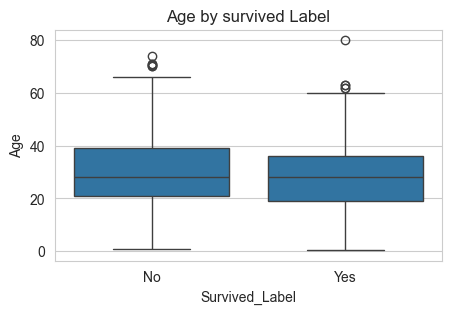

In [19]:
plt.figure(figsize=(5,3))
sns.boxplot(x = df["survived_label"], y = df["age"])
plt.xlabel("Survived_Label")
plt.ylabel("Age")
plt.title("Age by survived Label")
plt.show()

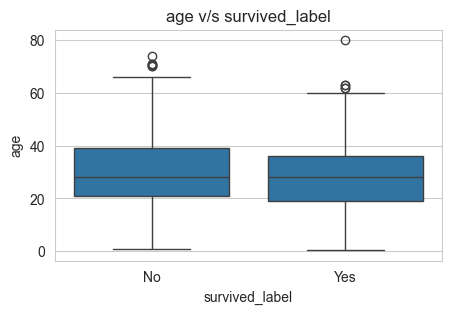

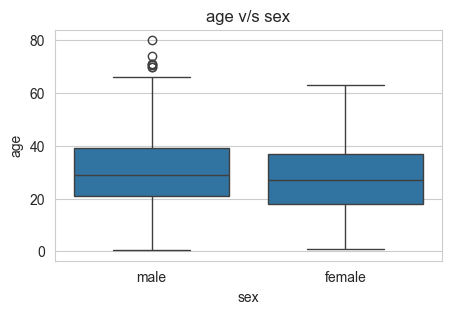

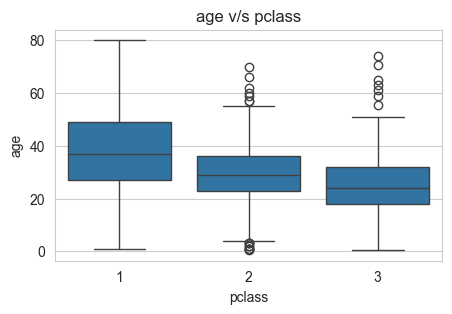

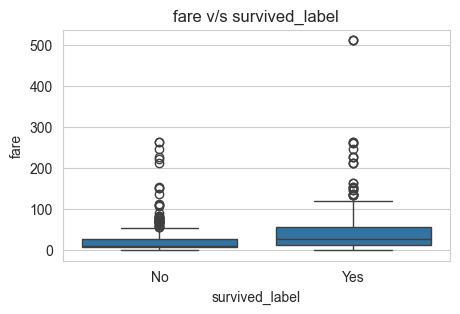

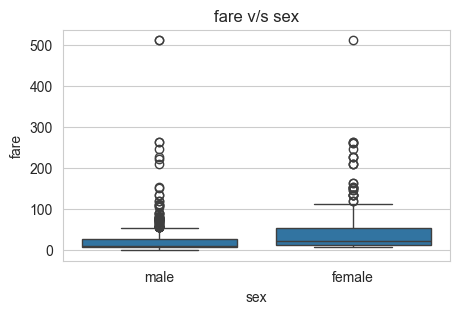

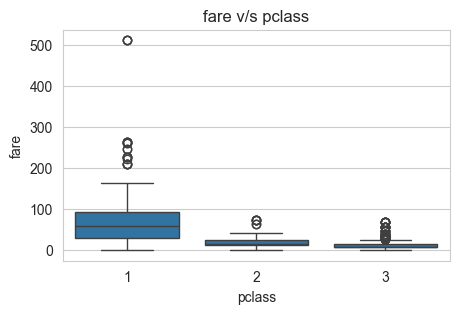

In [20]:
num_for_box = ["age", "fare"]
cat_for_box = ["survived_label", "sex", "pclass"]

for num in num_for_box:
    for cat in cat_for_box:
        plt.figure(figsize=(5,3))
        sns.boxplot(x = df[cat], y = df[num])
        plt.title(f"{num} v/s {cat}")
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

In [21]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


In [25]:
df[num_cols + ["survived_label"]]

,age,fare,sibsp,parch,survived_label
0,22.0,7.2500,1,0,No
1,38.0,71.2833,1,0,Yes
2,26.0,7.9250,0,0,Yes
3,35.0,53.1000,1,0,Yes
4,35.0,8.0500,0,0,No
...,...,...,...,...,...
886,27.0,13.0000,0,0,No
887,19.0,30.0000,0,0,Yes
888,NaN,23.4500,1,2,No
889,26.0,30.0000,0,0,Yes


In [29]:
df[num_cols + ["survived_label"]].groupby("survived_label").mean()

,age,fare,sibsp,parch
survived_label,,,,
No,30.626179,22.117887,0.553734,0.329690
Yes,28.343690,48.395408,0.473684,0.464912


In [31]:
for cat in ["survived_label", "sex", "pclass"]:
    print(f"Grouped Statistics for fare by {cat}:")
    #print(df.groupby(cat)["fare"].describe())
    print(df.groupby(cat)["fare"].mean())
    print("-"* 120)

Grouped Statistics for fare by survived_label:
survived_label
No     22.117887
Yes    48.395408
Name: fare, dtype: float64
------------------------------------------------------------------------------------------------------------------------
Grouped Statistics for fare by sex:
sex
female    44.479818
male      25.523893
Name: fare, dtype: float64
------------------------------------------------------------------------------------------------------------------------
Grouped Statistics for fare by pclass:
pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64
------------------------------------------------------------------------------------------------------------------------


**4. Categorical v/s Categorical Features**

**4.1 Crosstab Examples**

In [34]:
print("Crosstab sex v/s survived")
print(pd.crosstab(df["sex"], df["survived_label"]))

print("-" * 120)

print("Crosstab pclass v/s survived")
print(pd.crosstab(df["pclass"], df["survived_label"]))

Crosstab sex v/s survived
survived_label   No  Yes
sex                     
female           81  233
male            468  109
------------------------------------------------------------------------------------------------------------------------
Crosstab pclass v/s survived
survived_label   No  Yes
pclass                  
1                80  136
2                97   87
3               372  119


**4.2 Countplot**

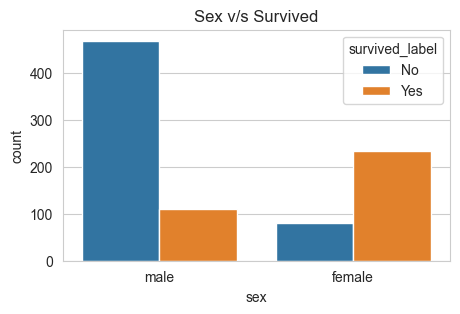

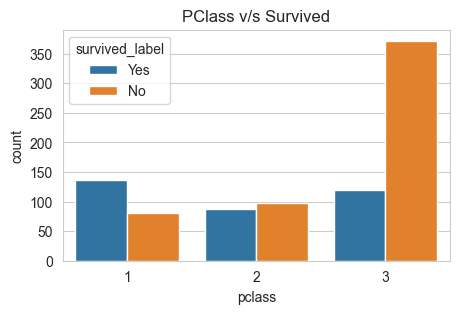

In [36]:
plt.figure(figsize=(5,3))
sns.countplot(x = df["sex"], hue= df["survived_label"])
plt.title("Sex v/s Survived")
plt.show()

plt.figure(figsize=(5,3))
sns.countplot(x = df["pclass"], hue= df["survived_label"])
plt.title("PClass v/s Survived")
plt.show()